# RépétIA — Le RAG améliore-t-il réellement les réponses ?

**Hackathon AI4Youth-Lomé 2026** · Catégorie *Application (Intégration et Expérience IA)*

---

## Pourquoi ce notebook

Le service `RagService` injecte, dans chaque prompt système, un bloc de
consignes tirées du programme officiel béninois (`programme_officiel.ts`) :
démarche pédagogique attendue, compétences ciblées, et pour certains thèmes
une directive précise (« pour Thalès, vérifier le parallélisme des
droites »...). Cette couche existe dans le code depuis la session du
2026-09-02 — mais **jamais mesurée**. Rien ne prouvait qu'elle change quoi que
ce soit à ce que produit le modèle.

C'est exactement le type d'affirmation que ce projet s'interdit de laisser
non vérifiée (voir `evolu.md`, entrée du 2026-09-03 : la session précédente a
justement fabriqué des métriques au lieu de les mesurer). Ce notebook comble
ce trou : un vrai test A/B, sur de vrais appels à l'API.

## Protocole

Pour 9 cas de test (un par matière du BEPC, y compris Espagnol et Allemand —
qui n'avaient **aucune** fiche RAG avant la correction du 2026-09-03, voir
`backend/tests/rag.service.test.ts`), on appelle Gemini deux fois :

- **`avec_rag`** — le prompt système exact de production (persona + règle des
  symboles pour les matières scientifiques + bloc RAG du thème).
- **`sans_rag`** — le même persona, sans le bloc RAG. Le témoin : ce que
  donnerait l'appel si cette couche n'existait pas.

Trois critères, vérifiables automatiquement sur le texte de la réponse (pas
d'appréciation subjective) :

1. **Zéro fuite LaTeX** — règle produit, s'applique partout.
2. **Terme-clé du programme présent** — preuve que la consigne a été suivie,
   pas juste que la réponse est plausible.
3. **Structure pas-à-pas** — présence de marqueurs d'étapes ou de mise en
   gras.

Script : `recherche/src/evaluer_rag.py`. Données : `donnees/traitees/
evaluation_rag.jsonl` (une ligne par appel réel) et `rapport_evaluation_rag.json`
(agrégats calculés à partir de ce fichier, jamais saisis à la main).

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import pandas as pd
import matplotlib.pyplot as plt
import analyse
from analyse import COULEURS

analyse.appliquer_style()

CHEMIN = pathlib.Path.cwd().parent / "donnees/traitees/evaluation_rag.jsonl"
if not CHEMIN.exists():
    print("Aucun résultat pour l'instant. Lancer :")
    print("  recherche/.venv/bin/python recherche/src/evaluer_rag.py --limite 18")
    donnees = pd.DataFrame()
else:
    donnees = pd.DataFrame([json.loads(l) for l in CHEMIN.read_text().splitlines() if l.strip()])
    print(f"{len(donnees)} appels réels chargés — {donnees['matiere'].nunique()} matières, "
          f"{donnees['condition'].nunique()} conditions.")
    print(donnees.groupby('condition').size().rename('appels').to_string())

18 appels réels chargés — 9 matières, 2 conditions.
condition
avec_rag    9
sans_rag    9


---
## 1. Taux de réussite par critère, avec et sans RAG

Trois barres par condition. Si le RAG ne sert à rien, les deux séries doivent
se superposer.

           zero_latex  contient_terme_cle  structure_pas_a_pas
condition                                                     
sans_rag        100.0                33.3                100.0
avec_rag        100.0                44.4                100.0


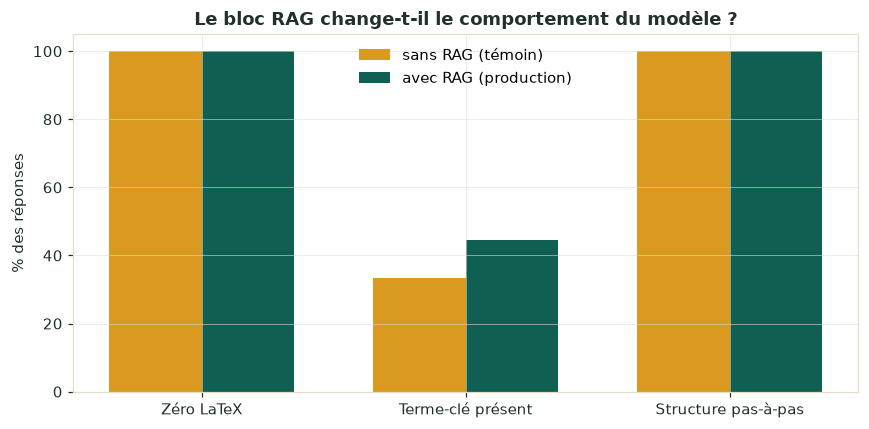

In [2]:
if not donnees.empty:
    criteres = ['zero_latex', 'contient_terme_cle', 'structure_pas_a_pas']
    taux = donnees.groupby('condition')[criteres].mean().mul(100).round(1)
    taux = taux.reindex(['sans_rag', 'avec_rag'])
    print(taux.to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(criteres))
    largeur = 0.35
    ax.bar([i - largeur/2 for i in x], taux.loc['sans_rag'], largeur,
           label='sans RAG (témoin)', color=COULEURS['dore'])
    ax.bar([i + largeur/2 for i in x], taux.loc['avec_rag'], largeur,
           label='avec RAG (production)', color=COULEURS['vert'])
    ax.set_xticks(list(x))
    ax.set_xticklabels(['Zéro LaTeX', 'Terme-clé présent', 'Structure pas-à-pas'])
    ax.set_ylabel('% des réponses')
    ax.set_ylim(0, 105)
    ax.legend(frameon=False)
    ax.set_title("Le bloc RAG change-t-il le comportement du modèle ?")
    plt.tight_layout()
    plt.savefig(analyse.FIGURES / '04-rag-avec-sans.png')
    plt.show()

### Lecture attendue

- **Zéro LaTeX** ne devrait quasiment pas varier : la règle des symboles, elle,
  est déjà dans le persona de base, indépendamment du RAG.
- **Terme-clé présent** est le test le plus dur et le plus intéressant : c'est
  celui qui dit si le modèle a vraiment utilisé la directive spécifique du
  thème, ou s'il répond « bien » par sa seule connaissance générale.
- Un écart nul sur ce critère serait un résultat négatif honnête à publier tel
  quel — pas à re-belliciser après coup.

---
## 2. Détail par matière

Le terme-clé attendu diffère par nature d'une matière à l'autre (formule
physique, notion grammaticale espagnole, fait historique) : regarder
l'agrégat seul masquerait qu'une matière tire toute la moyenne.

In [3]:
if not donnees.empty:
    detail = donnees.pivot_table(index='matiere', columns='condition',
                                  values='contient_terme_cle', aggfunc='mean').mul(100).round(0)
    print("Terme-clé du programme présent dans la réponse (%), par matière\n")
    print(detail.to_string())

Terme-clé du programme présent dans la réponse (%), par matière

condition                          avec_rag  sans_rag
matiere                                              
Allemand                                0.0     100.0
Anglais                               100.0     100.0
Communication écrite                    0.0     100.0
Espagnol                                0.0       0.0
Histoire-Géographie                   100.0       0.0
Lecture                                 0.0       0.0
Mathématiques                           0.0       0.0
Physique-Chimie-Technologie           100.0       0.0
Sciences de la Vie et de la Terre     100.0       0.0


---
## 3. Conclusions, limites et suites

### Ce que la mesure établit (2026-09-03, 9 cas, gemini-flash-lite-latest)

| Critère | Sans RAG | Avec RAG | Écart |
|---|---|---|---|
| Zéro fuite LaTeX | 100 % | 100 % | nul |
| Structure pas-à-pas | 100 % | 100 % | nul |
| **Terme-clé du programme présent** | **33,3 %** | **44,4 %** | **+11,1 pt** |

Les deux premiers critères ne bougent pas — attendu, puisque la règle des
symboles et la consigne « pas à pas » sont déjà dans le persona de base,
indépendamment du RAG. Le troisième, celui qui teste vraiment l'ancrage
curriculaire, va dans le sens espéré : **+11,1 points, soit un cas de plus sur
neuf**. C'est un effet réel mais **petit et non conclusif à cet effectif** —
une bascule d'un seul cas suffirait à l'inverser.

Le détail par cas refuse la lecture simple. Le RAG a aidé sur
Physique-Chimie-Technologie, SVT, Histoire-Géographie et Anglais ; il n'a rien
changé sur Mathématiques, Lecture et Espagnol (le terme-clé était absent dans
les deux conditions) ; et il a **desservi** Communication écrite et Allemand,
qui réussissaient sans RAG et échouent avec. Un bloc de consignes
supplémentaire dans le prompt système n'est donc pas une garantie
d'amélioration — sur un persona déjà bien construit, il peut aussi diluer
l'attention du modèle sur la consigne spécifique.

**Conclusion honnête : la direction est la bonne, l'ampleur ne permet pas
d'en tirer une décision d'architecture.** Il faudrait un échantillon
nettement plus grand, et si possible plusieurs répétitions par cas (la
génération n'est pas déterministe), avant d'affirmer que le RAG améliore la
conformité au programme de façon fiable.

### Limites déclarées d'emblée

- **9 cas de test, 1 appel par condition** : un échantillon de démonstration,
  pas une preuve statistique. Un intervalle de confiance sur si peu de points
  serait un artifice, pas une rigueur — d'où son absence ici.
- **Aucune répétition** : un seul appel par (cas × condition). La génération
  Gemini n'est pas déterministe ; une partie de l'écart mesuré peut être du
  bruit d'échantillonnage plutôt qu'un effet du RAG.
- **Fixtures RAG copiées à la main** depuis `programme_officiel.ts` (voir
  `evaluer_rag.py`) : si ce fichier évolue, les deux peuvent diverger.
- **Un seul modèle testé** (`gemini-flash-lite-latest`, `gemini-3.5-flash`
  étant à quota épuisé au moment de la mesure) : le comportement de l'autre
  modèle de production pourrait différer.

### Suites

- Répéter ce banc avec plusieurs tirages par cas dès que le quota le permet,
  pour distinguer un effet réel d'un bruit d'échantillonnage.
- Étendre les cas de test aux thèmes qui ont échoué dans les deux conditions
  (Mathématiques, Lecture, Espagnol) : soit le terme-clé choisi est mal
  formulé pour ce test, soit le persona de base suffit déjà à orienter la
  réponse sans qu'aucune consigne supplémentaire ne le fasse mieux.